### Notebook made for inference purposes

In [ ]:
%cd ../src/u-net-vit

In [21]:
Data_path = "../../data/MARIDA/"

It is imperative to run a first time the evaluation.py to create the segmentation masks

In [ ]:
!python evaluation.py --data_path {Data_path} --model_path checkpoints/best_model/best_model.pth --  True

In [24]:
from dataloader import GenDEBRIS, bands_mean, bands_std
import torchvision.transforms as transforms

In [25]:

transform_test = transforms.Compose([transforms.ToTensor()])
standardization = transforms.Normalize(bands_mean, bands_std)
dataset_test = GenDEBRIS('test', transform=transform_test, standardization = standardization, path = Data_path, agg_to_water = True)

Load test set to memory:   0%|          | 0/359 [00:00<?, ?it/s]

Load test set to memory: 100%|██████████| 359/359 [00:15<00:00, 22.50it/s]


#### Pick any patch from the test set randomly to visualize

In [ ]:
import random 
name = random.choice(dataset_test.getnames())
print(name)

3-11-16_16PDC_10


In [73]:
import os, numpy as np, rasterio, matplotlib.pyplot as plt
import sys; sys.path.insert(0, '..')
from utils.assets import labels_agg, color_mapping, S2_RGB_INDICES

In [74]:
roi_folder = '_'.join(['S2'] + name.split('_')[:-1]) 
roi_name   = '_'.join(['S2'] + name.split('_'))        

In [75]:
src_tif  = os.path.join(Data_path, 'patches', roi_folder, roi_name + '.tif')
pred_dir = 'data/predicted_unet'
pred_tif = os.path.join(pred_dir, roi_name + '_vitunet.tif')

#### The following code is made with the help of Claude. 

Since the patches are 11 bands and to visualize it is needed to pass to RGB I did not want to spend my time 
figuring out how to code it. Note that the Marida study uses directly the QGIS tool at https://qgis.org/ which is more straightforward but manual. This is a work around to have an inference notebook ready to run and visualize results

Prompt: given "labels_agg = ['Marine Debris','Dense Sargassum','Sparse Sargassum',
              'Natural Organic Material','Ship','Clouds','Marine Water','Sediment-Laden Water',
              'Foam','Turbid Water','Shallow Water']" , "color_mapping ={'Marine Debris': 'red',
               'Dense Sargassum': 'green',
               'Sparse Sargassum': 'limegreen',
               'Marine Water': 'navy',
               'Foam': 'purple',
               'Clouds': 'silver',
               'Cloud Shadows': 'gray',
               'Natural Organic Material': 'brown',
               'Ship': 'orange',
               'Wakes': 'yellow',
               'Shallow Water': 'darkturquoise',
               'Turbid Water': 'darkkhaki',
               'Sediment-Laden Water': 'gold',
               'Waves': 'seashell',
               'Mixed Water': 'rosybrown'}" and "S2_RGB_INDICES = [3, 2, 1]"  create python code to take a rasterio tif image and a tif mask of 11 bands, show the plots of the RGB original image and the segmented generated mask next to it.

In [76]:
from matplotlib.colors import ListedColormap, to_rgb
from matplotlib.patches import Patch

In [77]:
with rasterio.open(src_tif)  as s: image = np.moveaxis(s.read(), 0, -1).astype('float32')
with rasterio.open(pred_tif) as s: mask  = s.read(1)

In [92]:
def show_prediction(image, mask, roi_name=''):
    rgb = image[..., S2_RGB_INDICES]
    lo, hi = np.nanpercentile(rgb, 2), np.nanpercentile(rgb, 98)
    rgb = np.clip((rgb - lo) / (hi - lo + 1e-8), 0, 1)

    cmap = ListedColormap([to_rgb(color_mapping[c]) for c in labels_agg])

    fig, ax = plt.subplots(1, 2, figsize=(11, 5))
    ax[0].imshow(rgb); ax[0].set_title('RGB (B4/B3/B2)'); ax[0].axis('off')
    ax[1].imshow(mask - 1, cmap=cmap, vmin=0, vmax=len(labels_agg)-1); ax[1].set_title('ViT-UNet mask'); ax[1].axis('off')
    fig.legend(handles=[Patch(color=to_rgb(color_mapping[c]), label=c) for c in labels_agg],
                 loc='center right', bbox_to_anchor=(1.18, 0.5), frameon=False)
    fig.suptitle(roi_name)
    plt.show()

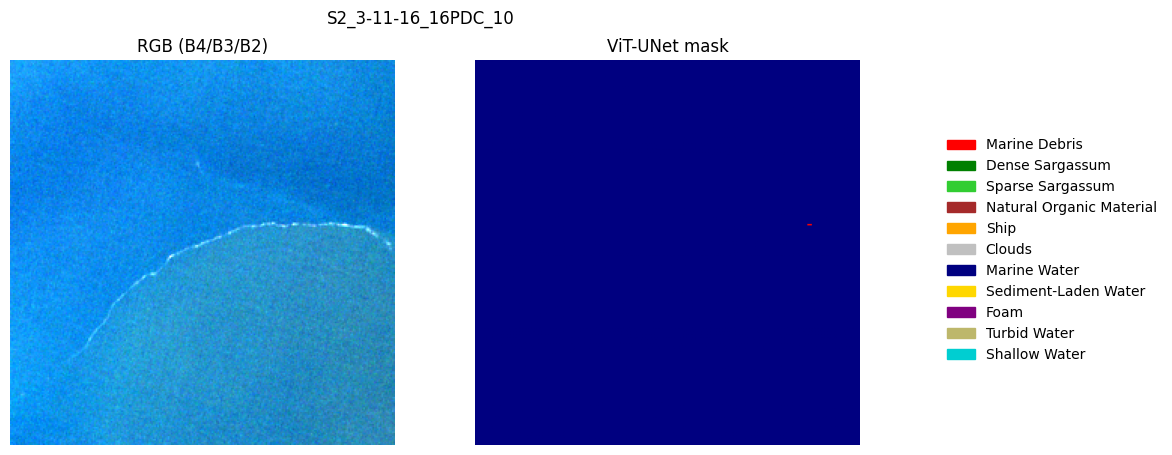

In [79]:
show_prediction(image, mask, roi_name)

### Fixed patch to visualize 

patch: 3-11-16_16PDC_14

In [117]:
#name_fixed = '3-11-16_16PDC_14'
#name_fixed = '27-1-19_16QED_14'
#name_fixed = '14-9-18_16PCC_13'
name_fixed = '22-12-20_18QYF_0'
roi_folder_fixed = '_'.join(['S2'] + name_fixed.split('_')[:-1]) 
roi_name_fixed   = '_'.join(['S2'] + name_fixed.split('_'))    
src_tif  = os.path.join(Data_path, 'patches', roi_folder_fixed, roi_name_fixed + '.tif')
pred_dir = 'data/predicted_unet'
pred_tif = os.path.join(pred_dir, roi_name_fixed + '_vitunet.tif')

In [118]:
with rasterio.open(src_tif)  as s: image_fixed = np.moveaxis(s.read(), 0, -1).astype('float32')
with rasterio.open(pred_tif) as s: mask_fixed  = s.read(1)

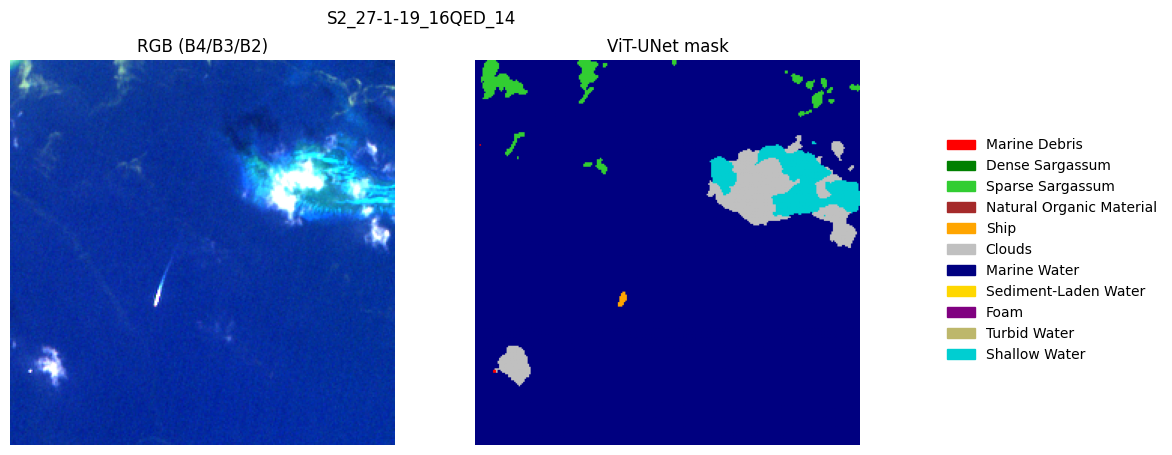

In [111]:
show_prediction(image_fixed, mask_fixed, roi_name_fixed)

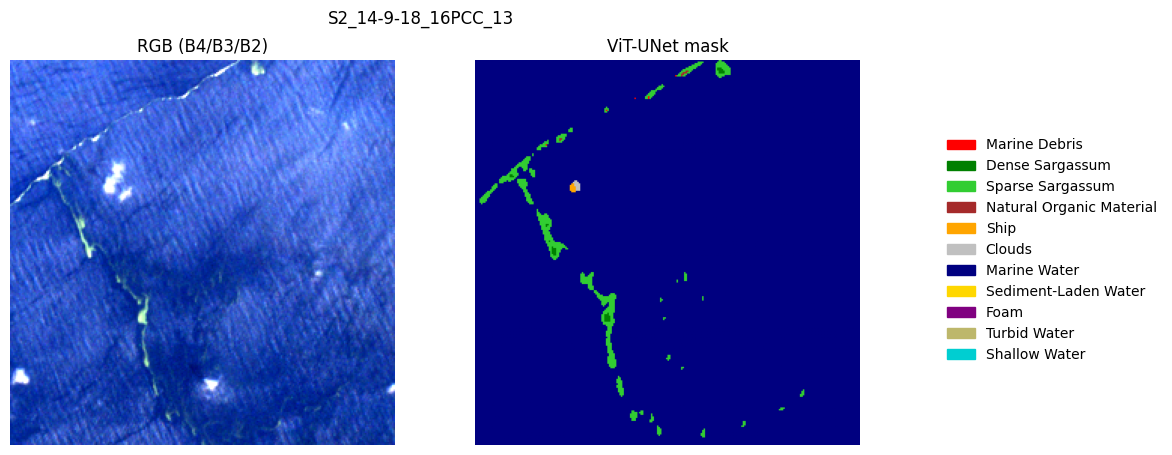

In [114]:
show_prediction(image_fixed, mask_fixed, roi_name_fixed)

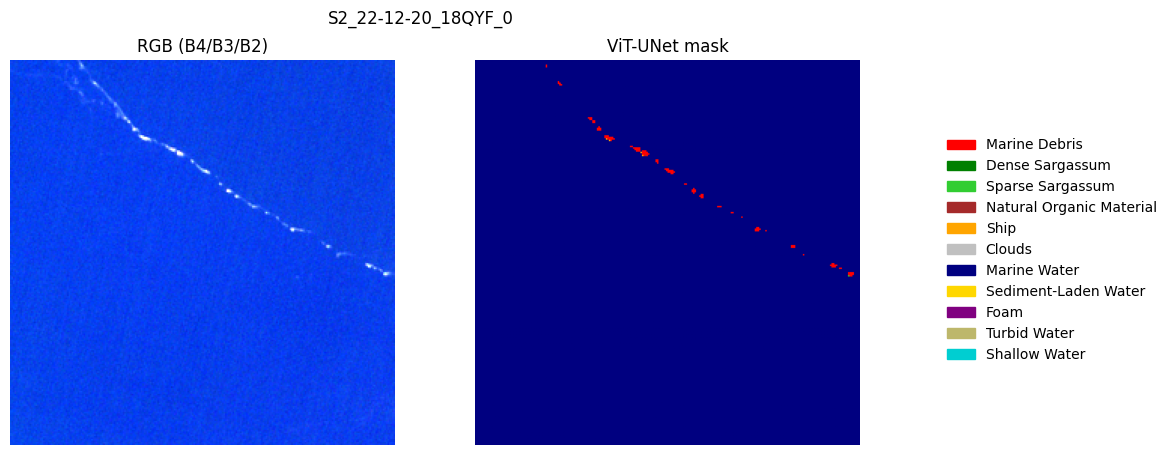

In [119]:
show_prediction(image_fixed, mask_fixed, roi_name_fixed)